## Predictive Maintenance: Machine Failure Prediction

## Project Overview

This project develops a machine learning system to predict machine failures
using operational and sensor-related measurements.

The objective is to identify machines at higher risk of failure so that
maintenance can potentially be scheduled before an unexpected failure occurs.

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
pe = pd.read_csv(r"C:\Users\saksh\Downloads\Predictive Equipment Dataset.csv")

In [84]:
pe.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   UDI                                 10000 non-null  int64  
 1   Product ID                          10000 non-null  str    
 2   Type                                10000 non-null  str    
 3   Air temperature [K]                 10000 non-null  float64
 4   Process temperature [K]             10000 non-null  float64
 5   Rotational speed [rpm]              10000 non-null  int64  
 6   Torque [Nm]                         10000 non-null  float64
 7   Tool wear [min]                     10000 non-null  int64  
 8   Machine failure                     10000 non-null  int64  
 9   Tool wear failure                   10000 non-null  int64  
 10  Heat dissipation failure indicator  10000 non-null  int64  
 11  Power failure indicator             10000 non-null  i

In [85]:
pe.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Tool wear failure,Heat dissipation failure indicator,Power failure indicator,Overstrain failure indicator,Random failure indicator
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Business Problem

Unexpected equipment failures can result in production downtime,
maintenance costs, and operational disruptions.

Predictive maintenance uses historical machine and sensor data to
identify patterns associated with equipment failure.

In this project, the objective is to predict whether a machine will
experience a failure based on its operating conditions.

In [86]:
pe.shape

(10000, 14)

In [87]:
pe.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Tool wear failure,Heat dissipation failure indicator,Power failure indicator,Overstrain failure indicator,Random failure indicator
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [88]:
pe.isnull().sum()

UDI                                   0
Product ID                            0
Type                                  0
Air temperature [K]                   0
Process temperature [K]               0
Rotational speed [rpm]                0
Torque [Nm]                           0
Tool wear [min]                       0
Machine failure                       0
Tool wear failure                     0
Heat dissipation failure indicator    0
Power failure indicator               0
Overstrain failure indicator          0
Random failure indicator              0
dtype: int64

In [89]:
pe.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'Tool wear failure ',
       'Heat dissipation failure indicator', 'Power failure indicator',
       'Overstrain failure indicator', 'Random failure indicator'],
      dtype='str')

In [90]:
pe.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Tool wear failure,Heat dissipation failure indicator,Power failure indicator,Overstrain failure indicator,Random failure indicator
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [91]:
pe['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [92]:
pe.nunique()

UDI                                   10000
Product ID                            10000
Type                                      3
Air temperature [K]                      93
Process temperature [K]                  82
Rotational speed [rpm]                  941
Torque [Nm]                             577
Tool wear [min]                         246
Machine failure                           2
Tool wear failure                         2
Heat dissipation failure indicator        2
Power failure indicator                   2
Overstrain failure indicator              2
Random failure indicator                  2
dtype: int64

In [93]:
pe.isnull().sum()[pe.isnull().sum()>0]

Series([], dtype: int64)

In [94]:
pe['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [95]:
pe['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [96]:
pe = pe.drop(columns=['UDI', 'Product ID'])

In [97]:
pe.columns.tolist()

['Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'Tool wear failure ',
 'Heat dissipation failure indicator',
 'Power failure indicator',
 'Overstrain failure indicator',
 'Random failure indicator']

In [98]:
pe['Tool wear failure '].value_counts()

Tool wear failure 
0    9954
1      46
Name: count, dtype: int64

In [99]:
pe['Heat dissipation failure indicator'].value_counts()

Heat dissipation failure indicator
0    9885
1     115
Name: count, dtype: int64

In [100]:
pe['Power failure indicator'].value_counts()

Power failure indicator
0    9905
1      95
Name: count, dtype: int64

In [101]:
pe['Overstrain failure indicator'].value_counts()

Overstrain failure indicator
0    9902
1      98
Name: count, dtype: int64

In [102]:
pe['Random failure indicator'].value_counts()

Random failure indicator
0    9981
1      19
Name: count, dtype: int64

In [103]:
pd.crosstab(pe['Machine failure'], pe['Tool wear failure '])

Tool wear failure,0,1
Machine failure,,
0,9661,0
1,293,46


In [104]:
pe[['Tool wear failure ', 'Heat dissipation failure indicator', 'Power failure indicator', 'Overstrain failure indicator', 'Random failure indicator']].sum()

Tool wear failure                      46
Heat dissipation failure indicator    115
Power failure indicator                95
Overstrain failure indicator           98
Random failure indicator               19
dtype: int64

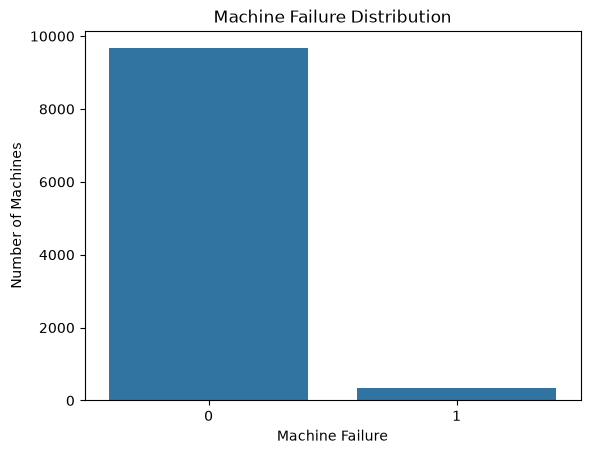

In [105]:
sns.countplot(x='Machine failure', data=pe)
plt.title('Machine Failure Distribution')
plt.xlabel('Machine Failure')
plt.ylabel('Number of Machines')
plt.show()

In [106]:
ft = pe.groupby('Type')['Machine failure'].mean() #Failure for each machine type.

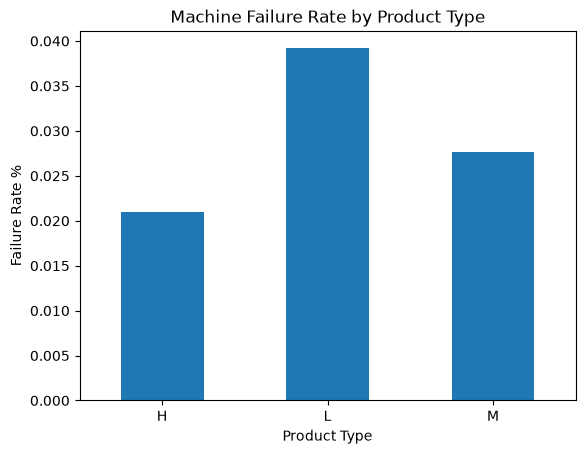

In [107]:
ft.plot(kind='bar')
plt.title('Machine Failure Rate by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Failure Rate %')
plt.xticks(rotation=0)
plt.show()

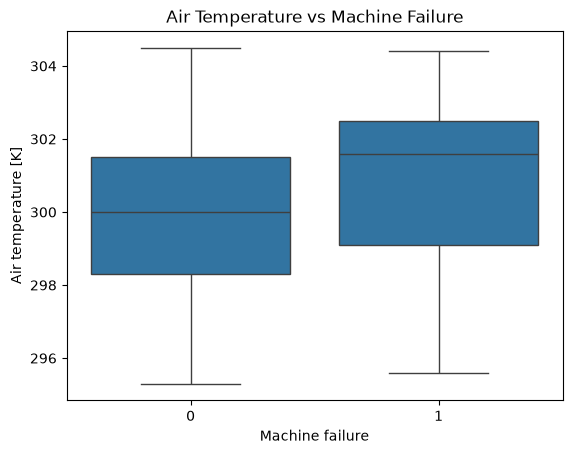

In [108]:
sns.boxplot(x='Machine failure', y='Air temperature [K]', data=pe)
plt.title('Air Temperature vs Machine Failure')
plt.show()

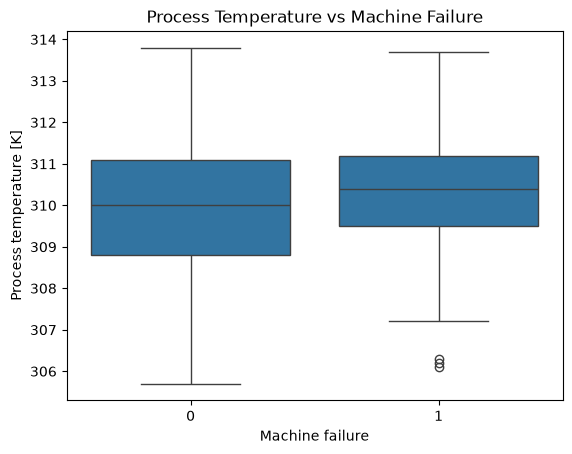

In [109]:
sns.boxplot(x='Machine failure', y='Process temperature [K]', data=pe)
plt.title('Process Temperature vs Machine Failure')
plt.show()

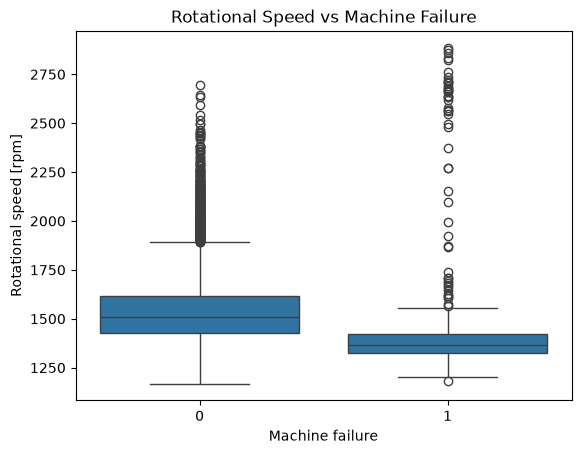

In [110]:
sns.boxplot(x='Machine failure', y='Rotational speed [rpm]', data=pe)
plt.title('Rotational Speed vs Machine Failure')
plt.show()

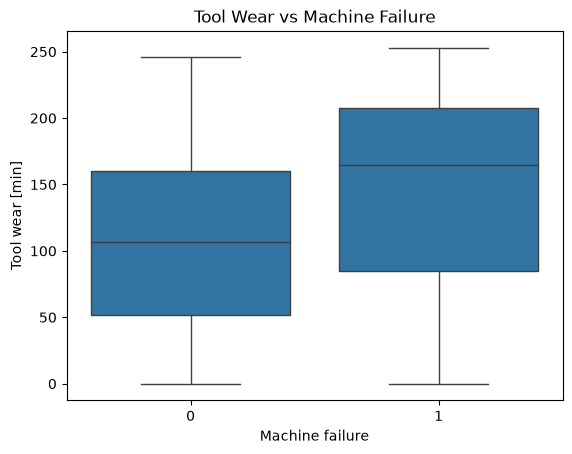

In [111]:
sns.boxplot(x='Machine failure', y='Tool wear [min]', data=pe)
plt.title('Tool Wear vs Machine Failure')
plt.show()

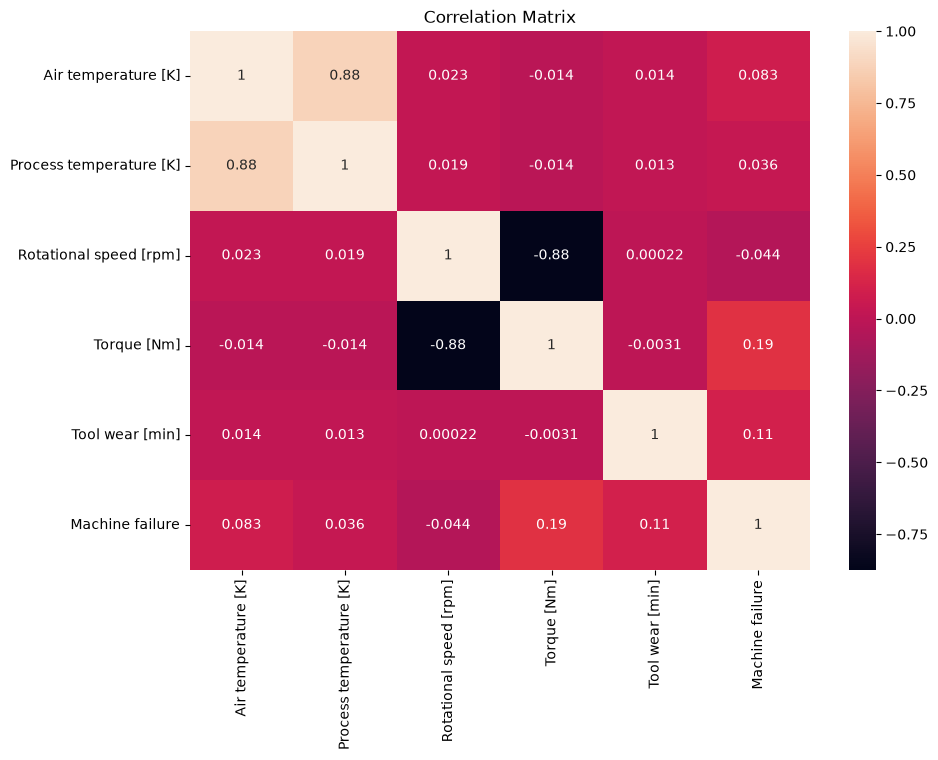

In [112]:
numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]

corr = pe[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

In [113]:
pe.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Tool wear failure ',
       'Heat dissipation failure indicator', 'Power failure indicator',
       'Overstrain failure indicator', 'Random failure indicator'],
      dtype='str')

In [114]:
pe.select_dtypes(include ='object').columns
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
pe[pe.select_dtypes(include='object').columns]=pe[pe.select_dtypes(include='object').columns].apply(le.fit_transform)

C:\Users\saksh\AppData\Local\Temp\ipykernel_25200\1933836909.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  pe.select_dtypes(include ='object').columns
C:\Users\saksh\AppData\Local\Temp\ipykernel_25200\1933836909.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3

In [115]:
features = ['Type','Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']

In [116]:
x = pe[features]
y = pe['Machine failure']

In [117]:
import sklearn
from sklearn.model_selection import train_test_split
pe_train_x, pe_test_x, pe_train_y, pe_test_y = train_test_split(x, y, test_size=0.2)
#pe = pd.concat([pe_train, pe_test], axis=0)

In [118]:
#pe_train_x = pe_train.drop('Machine failure', axis=1)
#pe_test_x = pe_test.drop('Machine failure', axis=1)
#pe_train_y = pe_train['Machine failure']
#pe_test_y = pe_test['Machine failure']

In [119]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, precision_score, f1_score

In [120]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(class_weight = 'balanced')
logreg.fit(pe_train_x, pe_train_y) #model build
log_pred = logreg.predict(pe_test_x)
print(confusion_matrix(pe_test_y, log_pred))
print(classification_report(pe_test_y, log_pred))

[[1548  388]
 [  13   51]]
              precision    recall  f1-score   support

           0       0.99      0.80      0.89      1936
           1       0.12      0.80      0.20        64

    accuracy                           0.80      2000
   macro avg       0.55      0.80      0.54      2000
weighted avg       0.96      0.80      0.86      2000



In [121]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(class_weight= 'balanced')
dt.fit(pe_train_x, pe_train_y)
dt_pred = dt.predict(pe_test_x)
print(confusion_matrix(pe_test_y, dt_pred))
print(classification_report(pe_test_y, dt_pred))

[[1919   17]
 [  24   40]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1936
           1       0.70      0.62      0.66        64

    accuracy                           0.98      2000
   macro avg       0.84      0.81      0.83      2000
weighted avg       0.98      0.98      0.98      2000



In [122]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(criterion='gini', n_estimators=200,max_depth=10)
rf.fit(pe_train_x,pe_train_y)
rf_pred = rf.predict(pe_test_x)
tab = confusion_matrix(pe_test_y, rf_pred)
print(tab)
print(classification_report(pe_test_y,rf_pred))

[[1932    4]
 [  25   39]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1936
           1       0.91      0.61      0.73        64

    accuracy                           0.99      2000
   macro avg       0.95      0.80      0.86      2000
weighted avg       0.98      0.99      0.98      2000



In [123]:
print(pe_train_x.columns.tolist())

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [124]:
dt.feature_importances_

array([0.00610635, 0.05383515, 0.01971958, 0.3461791 , 0.35634812,
       0.21781169])

In [125]:
pe_train_x.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
      dtype='str')

In [126]:
dt.feature_importances_.sum()

np.float64(0.9999999999999999)

In [127]:
feat_imp = pd.DataFrame()
feat_imp['Features'] = pe_train_x.columns
feat_imp['Imp'] = dt.feature_importances_

In [128]:
feat_imp.sort_values('Imp', ascending= False)

,Features,Imp
4,Torque [Nm],0.356348
3,Rotational speed [rpm],0.346179
5,Tool wear [min],0.217812
1,Air temperature [K],0.053835
2,Process temperature [K],0.019720
0,Type,0.006106


In [129]:
feat_imp

,Features,Imp
0,Type,0.006106
1,Air temperature [K],0.053835
2,Process temperature [K],0.019720
3,Rotational speed [rpm],0.346179
4,Torque [Nm],0.356348
5,Tool wear [min],0.217812


In [130]:
from sklearn.model_selection import GridSearchCV

In [131]:
search_dict = {'criterion' : ['gini', 'entropy'],
               'max_depth' : [2,3,4,5,6,7,8,9,10],
               'min_samples_split':[10, 15, 20, 25, 30, 35, 40, 45]}

In [132]:
from sklearn.model_selection import GridSearchCV
grid_model = GridSearchCV(dt, param_grid = search_dict)
grid_model.fit(pe_train_x, pe_train_y)
grid_model.best_params_

{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10}

In [133]:
tuned_pred = grid_model.predict(pe_test_x)
tab = confusion_matrix(pe_test_y,tuned_pred)
print(tab)
print(classification_report(pe_test_y, tuned_pred))

[[1842   94]
 [  17   47]]
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1936
           1       0.33      0.73      0.46        64

    accuracy                           0.94      2000
   macro avg       0.66      0.84      0.71      2000
weighted avg       0.97      0.94      0.95      2000



In [157]:
import joblib
joblib.dump(grid_model, "machine_failure_model.pkl")

['machine_failure_model.pkl']

In [158]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
print("Accuracy :", accuracy_score(pe_test_y, tuned_pred))
print("Precision:", precision_score(pe_test_y, tuned_pred))
print("Recall   :", recall_score(pe_test_y, tuned_pred))
print("F1 Score :", f1_score(pe_test_y, tuned_pred))

Accuracy : 0.9445
Precision: 0.3333333333333333
Recall   : 0.734375
F1 Score : 0.4585365853658537


In [159]:
prob = grid_model.predict_proba(pe_test_x)[:, 1]
print("ROC-AUC :", roc_auc_score(pe_test_y, prob))

ROC-AUC : 0.8700082321797521


In [160]:
error_analysis = pe_test_x.copy()
error_analysis['Actual'] = pe_test_y
error_analysis['Predicted'] = tuned_pred
false_positives = error_analysis[(error_analysis['Actual'] == 0) & (error_analysis['Predicted'] == 1)]
false_negatives = error_analysis[(error_analysis['Actual'] == 1) &(error_analysis['Predicted'] == 0)]
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 94
False Negatives: 17


In [161]:
print("FALSE POSITIVES")
print(false_positives)

FALSE POSITIVES
      Type  Air temperature [K]  Process temperature [K]  \
2333     1                299.2                    308.5   
9862     2                298.8                    309.7   
9965     1                298.3                    307.9   
1680     2                297.9                    307.4   
9666     2                299.1                    310.3   
...    ...                  ...                      ...   
845      1                296.3                    307.3   
3360     1                301.5                    310.6   
2164     1                299.6                    309.2   
3769     2                302.2                    311.0   
4466     1                302.8                    310.6   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Actual  Predicted  
2333                    1445         45.2              222       0          1  
9862                    1439         45.8               81       0          1  
9965                   

In [162]:
print("FALSE NEGATIVES")
print(false_negatives)

FALSE NEGATIVES
      Type  Air temperature [K]  Process temperature [K]  \
1087     0                296.9                    307.8   
3236     2                300.8                    309.4   
2941     2                300.7                    309.6   
4936     1                303.5                    312.4   
4851     1                303.7                    312.1   
8690     1                297.1                    308.5   
586      1                297.6                    309.6   
3266     1                301.3                    310.1   
5048     0                304.0                    313.2   
6159     1                301.0                    311.0   
1167     1                297.0                    308.1   
8357     1                298.5                    309.5   
3140     0                300.4                    309.9   
6932     1                300.8                    311.4   
9015     1                297.2                    308.1   
9613     1              

In [163]:
print("False Negative averages:")
print(false_negatives.mean(numeric_only=True))

False Negative averages:
Type                          1.000000
Air temperature [K]         299.994118
Process temperature [K]     310.158824
Rotational speed [rpm]     1487.647059
Torque [Nm]                  49.535294
Tool wear [min]             159.235294
Actual                        1.000000
Predicted                     0.000000
dtype: float64


In [164]:
true_positives = error_analysis[(error_analysis['Actual'] == 1) & (error_analysis['Predicted'] == 1)]
print("True Positive averages:")
print(true_positives.mean(numeric_only=True))

True Positive averages:
Type                          1.127660
Air temperature [K]         301.168085
Process temperature [K]     310.272340
Rotational speed [rpm]     1528.574468
Torque [Nm]                  50.168085
Tool wear [min]             122.574468
Actual                        1.000000
Predicted                     1.000000
dtype: float64


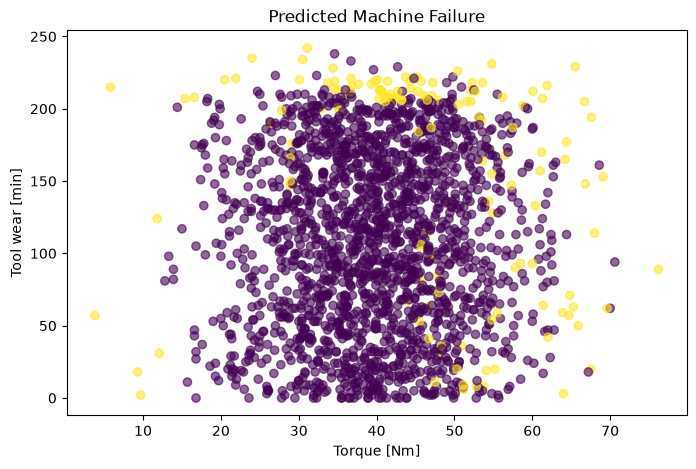

In [165]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(pe_test_x['Torque [Nm]'], pe_test_x['Tool wear [min]'], c=tuned_pred, alpha=0.6)
plt.xlabel('Torque [Nm]')
plt.ylabel('Tool wear [min]')
plt.title('Predicted Machine Failure')
plt.show()

In [166]:
from sklearn.inspection import permutation_importance

In [167]:
perm = permutation_importance(grid_model, pe_test_x, pe_test_y, n_repeats=10, random_state=42,scoring='f1')

In [168]:
perm_importance = pd.DataFrame({'Feature': pe_test_x.columns, 'Importance': perm.importances_mean})
perm_importance = perm_importance.sort_values(by='Importance',ascending=False)
print(perm_importance)

                   Feature  Importance
3   Rotational speed [rpm]    0.214329
1      Air temperature [K]    0.177850
4              Torque [Nm]    0.177697
5          Tool wear [min]    0.108859
2  Process temperature [K]    0.043836
0                     Type    0.021763


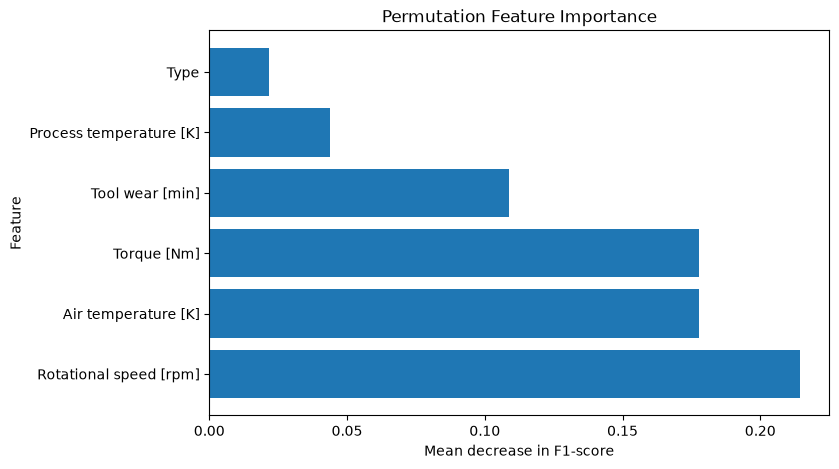

In [169]:
plt.figure(figsize=(8, 5))
plt.barh(perm_importance['Feature'], perm_importance['Importance'])
plt.xlabel('Mean decrease in F1-score')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance')
plt.show()

In [170]:
prob = grid_model.predict_proba(pe_test_x)[:, 1]

In [171]:
from sklearn.metrics import precision_score, recall_score, f1_score
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
for threshold in thresholds:
    threshold_pred = (prob >= threshold).astype(int)
    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision_score(pe_test_y, threshold_pred):.3f} | "
        f"Recall: {recall_score(pe_test_y, threshold_pred):.3f} | "
        f"F1: {f1_score(pe_test_y, threshold_pred):.3f}"
    )

Threshold: 0.2 | Precision: 0.301 | Recall: 0.766 | F1: 0.432
Threshold: 0.3 | Precision: 0.333 | Recall: 0.734 | F1: 0.459
Threshold: 0.4 | Precision: 0.333 | Recall: 0.734 | F1: 0.459
Threshold: 0.5 | Precision: 0.333 | Recall: 0.734 | F1: 0.459
Threshold: 0.6 | Precision: 0.333 | Recall: 0.734 | F1: 0.459
Threshold: 0.7 | Precision: 0.383 | Recall: 0.719 | F1: 0.500
Threshold: 0.8 | Precision: 0.407 | Recall: 0.688 | F1: 0.512


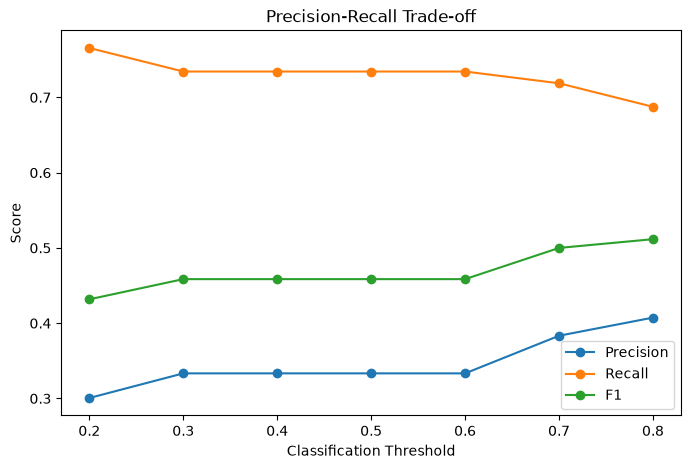

In [172]:
import matplotlib.pyplot as plt
precisions = []
recalls = []
f1_scores = []
for threshold in thresholds:
    threshold_pred = (prob >= threshold).astype(int)
    precisions.append(
        precision_score(pe_test_y, threshold_pred)
    )
    recalls.append(
        recall_score(pe_test_y, threshold_pred)
    )
    f1_scores.append(
        f1_score(pe_test_y, threshold_pred)
    )
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.plot(thresholds, f1_scores, marker='o', label='F1')

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off')
plt.legend()
plt.show()

In [173]:
prob = grid_model.predict_proba(pe_test_x)[:, 1]

In [174]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(pe_test_y, prob)

roc_auc = roc_auc_score(pe_test_y, prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8700082321797521


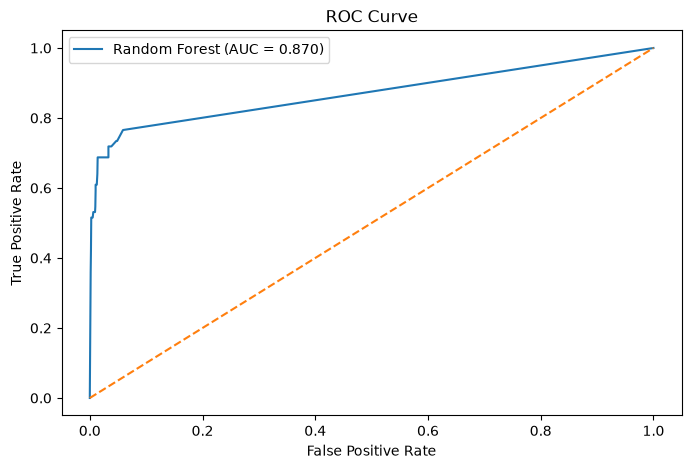

In [175]:
plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [176]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, thresholds_pr = precision_recall_curve(
    pe_test_y,
    prob
)

pr_auc = average_precision_score(pe_test_y, prob)

print("PR-AUC:", pr_auc)

PR-AUC: 0.5999307776580289


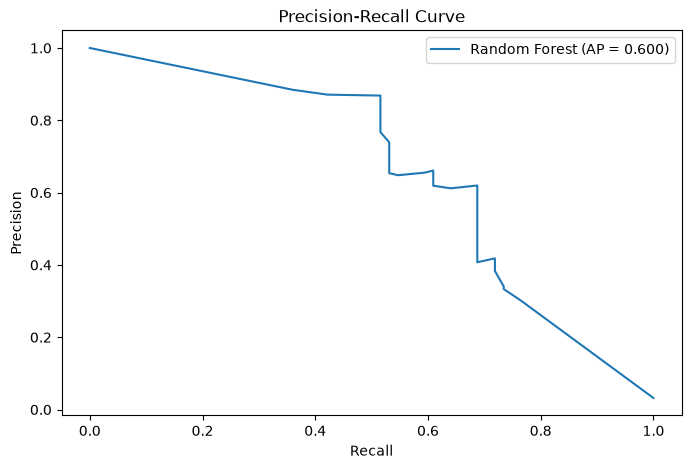

In [177]:
plt.figure(figsize=(8, 5))
plt.plot(recall,precision,label=f'Random Forest (AP = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [178]:
final_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        accuracy_score(pe_test_y, log_pred),
        accuracy_score(pe_test_y, dt_pred),
        accuracy_score(pe_test_y, rf_pred),
        accuracy_score(pe_test_y, tuned_pred)
    ],
    'Precision': [
        precision_score(pe_test_y, log_pred),
        precision_score(pe_test_y, dt_pred),
        precision_score(pe_test_y, rf_pred),
        precision_score(pe_test_y, tuned_pred)
    ],
    'Recall': [
        recall_score(pe_test_y, log_pred),
        recall_score(pe_test_y, dt_pred),
        recall_score(pe_test_y, rf_pred),
        recall_score(pe_test_y, tuned_pred)
    ],
    'F1 Score': [
        f1_score(pe_test_y, log_pred),
        f1_score(pe_test_y, dt_pred),
        f1_score(pe_test_y, rf_pred),
        f1_score(pe_test_y, tuned_pred)
    ]
})

print(final_comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.7995   0.116173  0.796875  0.202783
1        Decision Tree    0.9795   0.701754  0.625000  0.661157
2        Random Forest    0.9855   0.906977  0.609375  0.728972
3  Tuned Random Forest    0.9445   0.333333  0.734375  0.458537


In [179]:
import joblib
joblib.dump(grid_model, 'machine_failure_model.pkl')

['machine_failure_model.pkl']

In [180]:
features = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

## Conclusion

The project demonstrates an end-to-end machine learning workflow for
predictive maintenance, from exploratory analysis and feature selection
through model development, hyperparameter tuning, evaluation, and
interpretability.

The final model provides a way to identify machines with elevated
failure risk using operational characteristics.

The results also demonstrate the importance of evaluating imbalanced
classification problems using metrics beyond accuracy, particularly
precision, recall, F1-score, and PR-AUC.